In [82]:
def plot_eigenmode(solver, index, title_prefix=""):
    """
    Extracts and plots the vector field and magnitude of a specific eigenmode.
    """
    # 1. Extract the complex eigenvalue and get its real part
    eval_c = solver.eigenvalue(index)
    lr = np.real(eval_c)
    
    # 2. Extract the real eigenfunction
    vr, vi = solver.eigenfunction(index)
    
    # vr is the real part of the eigenfunction, living in your mixed space (V * Q)
    v_field = vr.subfunctions[0]
    
    # =================================================================
    # FIX 1: Project the Nédélec field to a standard CG vector space 
    # so the plotting backend can calculate the magnitude without crashing.
    # =================================================================
    mesh = v_field.function_space().mesh()
    V_plot = VectorFunctionSpace(mesh, "CG", 1)
    v_plot = project(v_field, V_plot)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # =================================================================
    # FIX 2: Safely combine f-strings and raw strings for the LaTeX math
    # =================================================================
    title_str = f"{title_prefix} Mode {index} - Vector Field\n" + r"$\lambda \approx$ " + f"{lr:.4f}"
    
    # 3. Plot the Vector Field (Arrows) using the projected field
    quiver(v_plot, axes=ax1)
    ax1.set_title(title_str)
    ax1.set_aspect('equal')
    
    # 4. Plot the Magnitude (Heatmap) using the projected field
    contour = tripcolor(v_plot, axes=ax2, cmap='inferno')
    fig.colorbar(contour, ax=ax2)
    ax2.set_title(f"{title_prefix} Mode {index} - Magnitude")
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()


def table_eigenvalues(eig_list, N_list, dof_list, h_list, exact_eigs=None):
    """
    Generates a table of eigenvalues across different solver runs using pandas.
    Only includes up to the top 10 eigenvalues.
    
    Parameters:
    eig_list (list of lists): The computed eigenvalues for each run.
    N_list (list of int): The mesh resolution (num_cells) for each run.
    dof_list (list of int): The number of Degrees of Freedom for each run.
    h_list (list of float): The maximum cell size (h) for each run.
    exact_eigs (list, optional): Exact eigenvalues to compute convergence rates.
    """
    assert len(eig_list) == len(N_list) == len(dof_list) == len(h_list), "Input lists must match in length."
    
    # Cap the maximum number of rows to 10
    max_eigs = min(10, max(len(run) for run in eig_list))
    
    # 1. Format the eigenvalues into strings and pad to max_eigs
    data_dict = {}
    for j, eigs in enumerate(eig_list):
        col = []
        # Slice the list to only process the first 10 eigenvalues
        for i, val in enumerate(eigs[:10]):
            
            # Format the computed eigenvalue
            if isinstance(val, complex) or np.iscomplexobj(val):
                val_str = f"{np.real(val):.5f} + {np.imag(val):.5f}i"
            else:
                val_str = f"{val:.5f}"
                
            # Compute convergence rate if exact eigenvalues are provided
            rate_str = ""
            if exact_eigs is not None and i < len(exact_eigs) and j > 0:
                exact_val = exact_eigs[i]
                
                # Check if the previous run had an eigenvalue at this index
                if i < len(eig_list[j-1]):
                    prev_val = eig_list[j-1][i]
                    
                    err_curr = abs(val - exact_val)
                    err_prev = abs(prev_val - exact_val)
                    
                    h_curr = h_list[j]
                    h_prev = h_list[j-1]
                    
                    # Prevent division by zero and log of zero errors
                    if h_curr != h_prev and err_curr > 1e-15 and err_prev > 1e-15:
                        # Use h_prev / h_curr to yield a positive rate since h decreases
                        rate = np.log(err_prev / err_curr) / np.log(h_prev / h_curr)
                        rate_str = f" ({rate:.2f})"
                    elif err_curr <= 1e-15:
                        # Reached machine precision / exact match
                        rate_str = " (exact)"
                        
            col.append(val_str + rate_str)
            
        # Pad missing eigenvalues with a dash up to max_eigs
        col += ["-"] * (max_eigs - len(col))
        
        # Create a combined column header for N and DOF
        col_header = f"N={N_list[j]} (DOF={dof_list[j]})"
        data_dict[col_header] = col
        
    # 2. Create the DataFrame
    df = pd.DataFrame(data_dict)

    # Use standard unicode for terminal/Jupyter row indices
    df.index = [f"λ_{i+1}" for i in range(max_eigs)]
    
    return df
    
def run_mesh_sweep(mesh_hierarchy, space_builder, form_builder, bc_builder, wind_func,
                   n_evals=32, solver_opts=None, drop_harmonic=False, **kwargs):
    """
    Iterates over a list or hierarchy of meshes, assembling and solving the eigenvalue 
    problem for each, and recording the computed eigenvalues and degrees of freedom.
    
    Parameters:
    mesh_hierarchy (list/iterable): A collection of Firedrake Mesh objects (e.g., from MeshHierarchy)
    space_builder (callable): Function to build the FunctionSpace (e.g., FEEC_B_N2_2d1k)
    form_builder (callable): Function to build the bilinear forms (e.g., B_formulation_2d1k)
    bc_builder (callable): Function to generate boundary conditions
    n_evals (int): Number of eigenvalues to compute
    solver_opts (dict): SLEPc/PETSc solver options
    drop_harmonic (bool): Flag to drop harmonic/zero modes from the result
    **kwargs: Additional parameters passed to the builders (e.g., degree=1, u=None, eps=Constant(1.0))
    
    Returns:
    eig_list (list of lists): The eigenvalues computed at each mesh level.
    dof_list (list of ints): The total degrees of freedom at each mesh level.
    N_list (list of ints): The cell counts at each mesh level.
    h_list (list of floats): The maximum cell sizes at each mesh level.
    """
    if solver_opts is None:
        solver_opts = {}

    eig_list = []
    dof_list = []
    N_list = []
    h_list = []  # Explicitly initialized here

    for mesh in mesh_hierarchy:
        u = wind_func(mesh)
        N_list.append(mesh.num_cells())
        
        # Rigorously extract max mesh size h
        V_dg0 = FunctionSpace(mesh, "DG", 0)
        
        # Create an empty Function, then interpolate the symbolic CellSize into it
        h_func = Function(V_dg0).interpolate(CellSize(mesh))
        
        # Now h_func is a computed data object, and we can access the underlying array
        h_max = h_func.dat.data_ro.max() 
        h_list.append(float(h_max)) # Cast to float to ensure it's a standard Python scalar
        
        # 1. Build the Function Space
        # Extract 'degree' from kwargs, default to 1 if not provided
        degree = kwargs.get('degree', 1)
        W = space_builder(mesh, degree=degree)
        
        # 2. Build the Bilinear Forms
        # Extract 'u' and 'eps' from kwargs, providing safe defaults
        eps = kwargs.get('eps', Constant(1.0))
        a, m = form_builder(W, u=u, eps=eps)
        
        # 3. Apply Boundary Conditions
        bcs = bc_builder(W)
        
        # 4. Setup and Solve
        eigenvalue_problem = make_eigensolver(a, m, bcs, n_evals=n_evals, opts=solver_opts)
        eigs, eigfs = solve_eigenpairs(eigenvalue_problem, drop_harmonic=drop_harmonic)
        
        # 5. Store Results
        eig_list.append(eigs)
        dof_list.append(W.dim())
        
    return eig_list, dof_list, N_list, h_list


def pacman_hierarchy(nlevels=4, mouth_angle=60.0, radius=1.0, maxh=0.25):
    base = make_pacman_mesh(mouth_angle=mouth_angle, radius=radius,
                            structured=False, maxh=maxh)
    mh = MeshHierarchy(base, nlevels)
    for m in mh:
        snap_rim(m, radius)
    return mh

def snap_rim(mesh, radius, rim_marker=1):
    V = mesh.coordinates.function_space()
    nodes = DirichletBC(V, Constant((0.0, 0.0)), rim_marker).nodes
    x = mesh.coordinates.dat.data
    r = np.linalg.norm(x[nodes], axis=1)
    keep = r > 1e-12
    x[nodes[keep]] *= (radius / r[keep])[:, None]



## 90 

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?


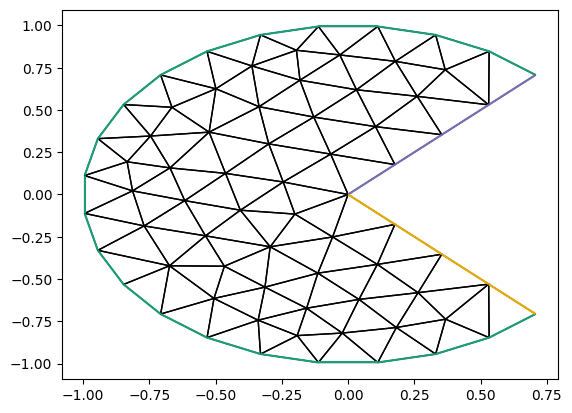

In [91]:
mh = pacman_hierarchy(nlevels=5, mouth_angle=90.0, radius=1.0, maxh=0.25)
triplot(mh[0])

In [95]:
def wind0(mesh):
    return None

# Map out the three combinations you listed
setups = [
    ("FEEC_B_N1", FEEC_B_N1_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_B_N2", FEEC_B_N2_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_A",    FEEC_A_2d1k,    A_formulation_2d1k, bcs_A_2d1k)
]

dataframes = []

for name, space, form, bc in setups:
    eigs, dofs, N_list, h_list = run_mesh_sweep(
        mesh_hierarchy=mh,
        space_builder=space,
        form_builder=form,
        bc_builder=bc,
        wind_func=wind0,
        n_evals=30,
        solver_opts=opts,
        drop_harmonic=True,
        degree=1,                                
        eps=Constant(1.0)        
    )
    
    # Store the dataframe returned by table_eigenvalues
    display(table_eigenvalues(eigs, N_list, dofs, h_list, exact_eigs=eigs[-1]))


,N=113 (DOF=256),N=452 (DOF=963),N=1808 (DOF=3733),N=7232 (DOF=14697),N=28928 (DOF=58321),N=115712 (DOF=232353)
λ_1,1.92473 + 0.00000i,1.94475 + 0.00000i (1.13),1.95515 + 0.00000i (1.29),1.95992 + 0.00000i (1.53),1.96197 + 0.00000i (2.11),1.96283 + 0.00000i (exact)
λ_2,5.16736 + 0.00000i,5.11414 + 0.00000i (2.17),5.10152 + 0.00000i (2.15),5.09846 + 0.00000i (2.29),5.09771 + 0.00000i (2.79),5.09752 + 0.00000i (exact)
λ_3,9.44416 + 0.00000i,9.35728 + 0.00000i (2.10),9.33558 + 0.00000i (2.11),9.33016 + 0.00000i (2.27),9.32881 + 0.00000i (2.78),9.32848 + 0.00000i (exact)
λ_4,14.77592 + 0.00000i,14.67223 + 0.00000i (1.60),14.63094 + 0.00000i (2.10),14.62051 + 0.00000i (2.27),14.61791 + 0.00000i (2.78),14.61726 + 0.00000i (exact)
λ_5,14.84840 + 0.00000i,14.70803 + 0.00000i (2.80),14.68834 + 0.00000i (2.14),14.68355 + 0.00000i (2.28),14.68236 + 0.00000i (2.79),14.68206 + 0.00000i (exact)
λ_6,21.22419 + 0.00000i,21.01066 + 0.00000i (2.09),20.95672 + 0.00000i (2.11),20.94326 + 0.00000i (2.27),20.93991 + 0.00000i (2.78),20.93907 + 0.00000i (exact)
λ_7,22.80361 + 0.00000i,23.23904 + 0.00000i (1.41),23.41054 + 0.00000i (1.42),23.48073 + 0.00000i (1.60),23.50934 + 0.00000i (2.15),23.52091 + 0.00000i (exact)
λ_8,28.68933 + 0.00000i,28.38184 + 0.00000i (2.07),28.30273 + 0.00000i (2.11),28.28295 + 0.00000i (2.27),28.27801 + 0.00000i (2.78),28.27678 + 0.00000i (exact)
λ_9,33.92255 + 0.00000i,33.69601 + 0.00000i (2.29),33.64619 + 0.00000i (2.31),33.63535 + 0.00000i (2.43),33.63294 + 0.00000i (2.92),33.63239 + 0.00000i (exact)
λ_10,37.20603 + 0.00000i,36.77006 + 0.00000i (2.04),36.65533 + 0.00000i (2.11),36.62652 + 0.00000i (2.27),36.61932 + 0.00000i (2.78),36.61753 + 0.00000i (exact)


,N=113 (DOF=624),N=452 (DOF=2377),N=1808 (DOF=9273),N=7232 (DOF=36625),N=28928 (DOF=145569),N=115712 (DOF=580417)
λ_1,1.97651 + 0.00000i,1.96507 + 0.00000i (3.06),1.96317 + 0.00000i (3.66),1.96309 + 0.00000i (-0.67),1.96323 + 0.00000i (1.52),1.96332 + 0.00000i (exact)
λ_2,5.19399 + 0.00000i,5.12158 + 0.00000i (2.10),5.10350 + 0.00000i (2.11),5.09897 + 0.00000i (2.26),5.09784 + 0.00000i (2.78),5.09755 + 0.00000i (exact)
λ_3,9.58019 + 0.00000i,9.39117 + 0.00000i (2.10),9.34407 + 0.00000i (2.11),9.33229 + 0.00000i (2.26),9.32935 + 0.00000i (2.78),9.32861 + 0.00000i (exact)
λ_4,15.20038 + 0.00000i,14.76181 + 0.00000i (2.11),14.65320 + 0.00000i (2.11),14.62608 + 0.00000i (2.27),14.61930 + 0.00000i (2.78),14.61761 + 0.00000i (exact)
λ_5,15.26217 + 0.00000i,14.82530 + 0.00000i (2.12),14.71768 + 0.00000i (2.12),14.69089 + 0.00000i (2.27),14.68420 + 0.00000i (2.78),14.68253 + 0.00000i (exact)
λ_6,21.98659 + 0.00000i,21.20047 + 0.00000i (2.10),21.00422 + 0.00000i (2.11),20.95516 + 0.00000i (2.27),20.94289 + 0.00000i (2.78),20.93982 + 0.00000i (exact)
λ_7,24.70929 + 0.00000i,23.80792 + 0.00000i (2.18),23.59041 + 0.00000i (2.28),23.54075 + 0.00000i (2.56),23.53034 + 0.00000i (3.31),23.52854 + 0.00000i (exact)
λ_8,30.13713 + 0.00000i,28.74089 + 0.00000i (2.10),28.39243 + 0.00000i (2.11),28.30539 + 0.00000i (2.27),28.28363 + 0.00000i (2.78),28.27819 + 0.00000i (exact)
λ_9,36.35310 + 0.00000i,34.30669 + 0.00000i (2.11),33.80047 + 0.00000i (2.11),33.67430 + 0.00000i (2.27),33.64277 + 0.00000i (2.78),33.63488 + 0.00000i (exact)
λ_10,39.66449 + 0.00000i,37.37880 + 0.00000i (2.10),36.80720 + 0.00000i (2.11),36.66450 + 0.00000i (2.27),36.62883 + 0.00000i (2.78),36.61991 + 0.00000i (exact)


,N=113 (DOF=72),N=452 (DOF=256),N=1808 (DOF=963),N=7232 (DOF=3733),N=28928 (DOF=14697),N=115712 (DOF=58321)
λ_1,2.05239 + 0.00000i,1.99479 + 0.00000i (1.60),1.97498 + 0.00000i (1.56),1.96779 + 0.00000i (1.70),1.96510 + 0.00000i (2.22),1.96407 + 0.00000i (exact)
λ_2,5.19601 + 0.00000i,5.12308 + 0.00000i (2.04),5.10401 + 0.00000i (2.08),5.09912 + 0.00000i (2.25),5.09788 + 0.00000i (2.76),5.09756 + 0.00000i (exact)
λ_3,9.64331 + 0.00000i,9.40770 + 0.00000i (2.09),9.34833 + 0.00000i (2.10),9.33338 + 0.00000i (2.26),9.32962 + 0.00000i (2.77),9.32868 + 0.00000i (exact)
λ_4,15.32189 + 0.00000i,14.79425 + 0.00000i (2.09),14.66161 + 0.00000i (2.10),14.62823 + 0.00000i (2.26),14.61985 + 0.00000i (2.77),14.61775 + 0.00000i (exact)
λ_5,15.50539 + 0.00000i,14.88652 + 0.00000i (2.11),14.73317 + 0.00000i (2.11),14.69481 + 0.00000i (2.26),14.68520 + 0.00000i (2.77),14.68279 + 0.00000i (exact)
λ_6,22.38413 + 0.00000i,21.30017 + 0.00000i (2.10),21.02964 + 0.00000i (2.10),20.96160 + 0.00000i (2.26),20.94452 + 0.00000i (2.77),20.94023 + 0.00000i (exact)
λ_7,26.62355 + 0.00000i,24.38858 + 0.00000i (1.95),23.78958 + 0.00000i (1.84),23.61303 + 0.00000i (1.92),23.55744 + 0.00000i (2.39),23.53892 + 0.00000i (exact)
λ_8,30.84033 + 0.00000i,28.91561 + 0.00000i (2.10),28.43683 + 0.00000i (2.10),28.31663 + 0.00000i (2.26),28.28648 + 0.00000i (2.77),28.27892 + 0.00000i (exact)
λ_9,37.65412 + 0.00000i,34.64029 + 0.00000i (2.09),33.88621 + 0.00000i (2.10),33.69623 + 0.00000i (2.26),33.64838 + 0.00000i (2.77),33.63634 + 0.00000i (exact)
λ_10,40.86014 + 0.00000i,37.67052 + 0.00000i (2.11),36.88100 + 0.00000i (2.11),36.68316 + 0.00000i (2.26),36.63356 + 0.00000i (2.77),36.62112 + 0.00000i (exact)


In [99]:
W = FEEC_B_N2_2d1k(mesh=mh[3], degree=1)
a, m = B_formulation_2d1k(W, u=None, eps=Constant(1.0))
bcs = bcs_B_2d1k(W)
eigensolver = make_eigensolver(a, m, bcs, 32, opts)
eig, eigf = solve_eigenpairs(eigensolver, drop_harmonic=False)

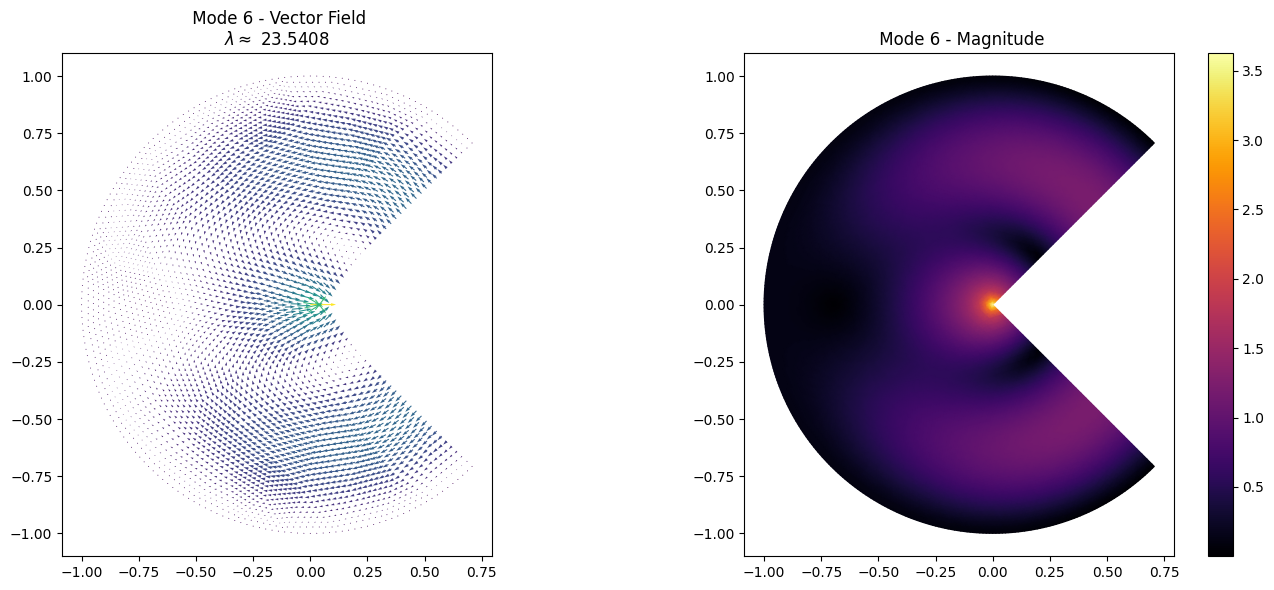

In [100]:
plot_eigenmode(eigensolver, 6, title_prefix="")

## 5 

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?


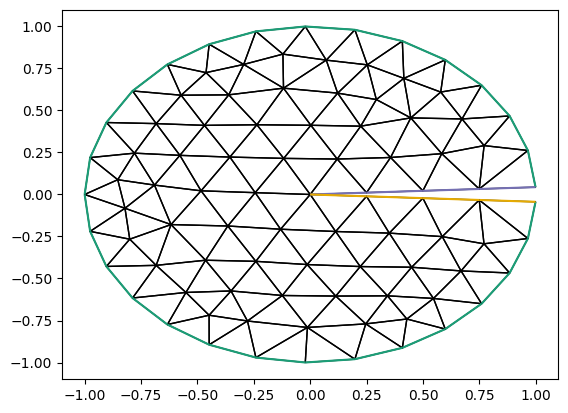

In [101]:
mh = pacman_hierarchy(nlevels=5, mouth_angle=5.0, radius=1.0, maxh=0.25)
triplot(mh[0])

In [102]:
def wind0(mesh):
    return None

# Map out the three combinations you listed
setups = [
    ("FEEC_B_N1", FEEC_B_N1_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_B_N2", FEEC_B_N2_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_A",    FEEC_A_2d1k,    A_formulation_2d1k, bcs_A_2d1k)
]

dataframes = []

for name, space, form, bc in setups:
    eigs, dofs, N_list, h_list = run_mesh_sweep(
        mesh_hierarchy=mh,
        space_builder=space,
        form_builder=form,
        bc_builder=bc,
        wind_func=wind0,
        n_evals=30,
        solver_opts=opts,
        drop_harmonic=True,
        degree=1,                                
        eps=Constant(1.0)        
    )
    
    # Store the dataframe returned by table_eigenvalues
    display(table_eigenvalues(eigs, N_list, dofs, h_list, exact_eigs=eigs[-1]))


,N=150 (DOF=337),N=600 (DOF=1273),N=2400 (DOF=4945),N=9600 (DOF=19489),N=38400 (DOF=77377),N=153600 (DOF=308353)
λ_1,1.26894 + 0.00000i,1.32133 + 0.00000i (0.98),1.35093 + 0.00000i (1.10),1.36657 + 0.00000i (1.31),1.37458 + 0.00000i (1.88),1.37860 + 0.00000i (exact)
λ_2,3.49961 + 0.00000i,3.46716 + 0.00000i (2.11),3.45914 + 0.00000i (2.11),3.45714 + 0.00000i (2.26),3.45665 + 0.00000i (2.77),3.45652 + 0.00000i (exact)
λ_3,6.26039 + 0.00000i,6.19963 + 0.00000i (2.15),6.18510 + 0.00000i (2.13),6.18154 + 0.00000i (2.28),6.18066 + 0.00000i (2.78),6.18044 + 0.00000i (exact)
λ_4,9.64569 + 0.00000i,9.55939 + 0.00000i (2.10),9.53781 + 0.00000i (2.11),9.53243 + 0.00000i (2.26),9.53108 + 0.00000i (2.77),9.53075 + 0.00000i (exact)
λ_5,13.67173 + 0.00000i,13.53688 + 0.00000i (2.09),13.50304 + 0.00000i (2.11),13.49460 + 0.00000i (2.26),13.49249 + 0.00000i (2.77),13.49196 + 0.00000i (exact)
λ_6,14.79314 + 0.00000i,14.70996 + 0.00000i (2.09),14.68897 + 0.00000i (2.11),14.68371 + 0.00000i (2.27),14.68240 + 0.00000i (2.78),14.68207 + 0.00000i (exact)
λ_7,18.31593 + 0.00000i,18.11768 + 0.00000i (2.12),18.06890 + 0.00000i (2.12),18.05679 + 0.00000i (2.27),18.05377 + 0.00000i (2.77),18.05301 + 0.00000i (exact)
λ_8,19.95125 + 0.00000i,20.59827 + 0.00000i (1.04),20.94023 + 0.00000i (1.12),21.11690 + 0.00000i (1.32),21.20643 + 0.00000i (1.89),21.25129 + 0.00000i (exact)
λ_9,23.50701 + 0.00000i,23.28177 + 0.00000i (2.07),23.22433 + 0.00000i (2.11),23.20998 + 0.00000i (2.26),23.20640 + 0.00000i (2.77),23.20551 + 0.00000i (exact)
λ_10,28.84180 + 0.00000i,28.69392 + 0.00000i (1.96),28.65222 + 0.00000i (2.08),28.64156 + 0.00000i (2.27),28.63889 + 0.00000i (2.79),28.63824 + 0.00000i (exact)


,N=150 (DOF=823),N=600 (DOF=3145),N=2400 (DOF=12289),N=9600 (DOF=48577),N=38400 (DOF=193153),N=153600 (DOF=770305)
λ_1,1.35654 + 0.00000i,1.36606 + 0.00000i (0.73),1.37346 + 0.00000i (0.99),1.37783 + 0.00000i (1.26),1.38018 + 0.00000i (1.86),1.38138 + 0.00000i (exact)
λ_2,3.51081 + 0.00000i,3.47002 + 0.00000i (2.10),3.45987 + 0.00000i (2.11),3.45733 + 0.00000i (2.26),3.45669 + 0.00000i (2.77),3.45653 + 0.00000i (exact)
λ_3,6.30902 + 0.00000i,6.21250 + 0.00000i (2.10),6.18841 + 0.00000i (2.11),6.18238 + 0.00000i (2.26),6.18087 + 0.00000i (2.77),6.18049 + 0.00000i (exact)
λ_4,9.78851 + 0.00000i,9.59490 + 0.00000i (2.10),9.54671 + 0.00000i (2.11),9.53466 + 0.00000i (2.26),9.53164 + 0.00000i (2.77),9.53089 + 0.00000i (exact)
λ_5,13.97514 + 0.00000i,13.61200 + 0.00000i (2.10),13.52183 + 0.00000i (2.11),13.49930 + 0.00000i (2.26),13.49367 + 0.00000i (2.77),13.49226 + 0.00000i (exact)
λ_6,15.26091 + 0.00000i,14.82497 + 0.00000i (2.11),14.71760 + 0.00000i (2.11),14.69087 + 0.00000i (2.26),14.68419 + 0.00000i (2.77),14.68253 + 0.00000i (exact)
λ_7,18.88029 + 0.00000i,18.25789 + 0.00000i (2.11),18.10398 + 0.00000i (2.11),18.06557 + 0.00000i (2.26),18.05596 + 0.00000i (2.77),18.05356 + 0.00000i (exact)
λ_8,21.89301 + 0.00000i,21.34409 + 0.00000i (3.48),21.25356 + 0.00000i (1.09),21.25777 + 0.00000i (0.24),21.27257 + 0.00000i (1.51),21.28313 + 0.00000i (exact)
λ_9,24.45743 + 0.00000i,23.51755 + 0.00000i (2.10),23.28327 + 0.00000i (2.11),23.22473 + 0.00000i (2.26),23.21009 + 0.00000i (2.77),23.20643 + 0.00000i (exact)
λ_10,30.65083 + 0.00000i,29.13555 + 0.00000i (2.11),28.76193 + 0.00000i (2.11),28.66898 + 0.00000i (2.26),28.64577 + 0.00000i (2.77),28.63997 + 0.00000i (exact)


,N=150 (DOF=94),N=600 (DOF=337),N=2400 (DOF=1273),N=9600 (DOF=4945),N=38400 (DOF=19489),N=153600 (DOF=77377)
λ_1,1.54172 + 0.00000i,1.45518 + 0.00000i (1.23),1.41716 + 0.00000i (1.22),1.39939 + 0.00000i (1.38),1.39084 + 0.00000i (1.92),1.38666 + 0.00000i (exact)
λ_2,3.50862 + 0.00000i,3.46965 + 0.00000i (2.08),3.45979 + 0.00000i (2.10),3.45731 + 0.00000i (2.26),3.45669 + 0.00000i (2.76),3.45653 + 0.00000i (exact)
λ_3,6.32208 + 0.00000i,6.21672 + 0.00000i (2.06),6.18957 + 0.00000i (2.09),6.18268 + 0.00000i (2.25),6.18095 + 0.00000i (2.76),6.18051 + 0.00000i (exact)
λ_4,9.85456 + 0.00000i,9.61198 + 0.00000i (2.09),9.55108 + 0.00000i (2.10),9.53576 + 0.00000i (2.26),9.53192 + 0.00000i (2.76),9.53096 + 0.00000i (exact)
λ_5,14.10683 + 0.00000i,13.64581 + 0.00000i (2.09),13.53046 + 0.00000i (2.10),13.50149 + 0.00000i (2.26),13.49422 + 0.00000i (2.76),13.49240 + 0.00000i (exact)
λ_6,15.49368 + 0.00000i,14.88305 + 0.00000i (2.11),14.73224 + 0.00000i (2.11),14.69457 + 0.00000i (2.26),14.68513 + 0.00000i (2.76),14.68277 + 0.00000i (exact)
λ_7,19.08833 + 0.00000i,18.31282 + 0.00000i (2.09),18.11809 + 0.00000i (2.10),18.06915 + 0.00000i (2.26),18.05688 + 0.00000i (2.76),18.05380 + 0.00000i (exact)
λ_8,24.91404 + 0.00000i,22.52015 + 0.00000i (1.67),21.77977 + 0.00000i (1.49),21.50667 + 0.00000i (1.54),21.39318 + 0.00000i (2.02),21.34223 + 0.00000i (exact)
λ_9,24.93591 + 0.00000i,23.63715 + 0.00000i (2.10),23.31361 + 0.00000i (2.10),23.23240 + 0.00000i (2.26),23.21204 + 0.00000i (2.76),23.20693 + 0.00000i (exact)
λ_10,31.56763 + 0.00000i,29.37296 + 0.00000i (2.09),28.82134 + 0.00000i (2.11),28.68395 + 0.00000i (2.26),28.64957 + 0.00000i (2.76),28.64095 + 0.00000i (exact)


- kings theorom is satisfied.
- the eigenvalues corresponding to eigenfunctions with the signularity also show lower than 2 convergence. (expected)
- - significnalty lower convergence rate for decrease in mouth angle. (expected)